# 2026 Dashboard for Tree Canopy Capstone

### Install Geospatial Dependencies

In [7]:
import subprocess, sys

packages = [
    "laspy[lazrs]",    # LAZ/LAS point cloud reading with Rust backend
    "rasterio",         # GeoTIFF read/write
    "rasterstats",         # GeoTIFF read/write
    "datashader",         # GeoTIFF read/write
    "matplotlib",         # MatPlotLibrary
    "pyproj>=3.4",      # CRS transformations (US survey feet → metres)
    "geopandas",        # Spatial dataframes
    "scipy",            # Local maxima detection for crown finding
    "plotly",           # Interactive dashboard charts
    "tqdm",             # Progress bars for tile processing
]

subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet"] + packages)
print("All packages installed successfully.")

All packages installed successfully.


### Environmental Support

In [8]:
# static PNG output inline
%matplotlib inline

In [12]:
import os
print(os.getcwd())

/home/ec2-user/SageMaker


### Verify S3 Access

In [3]:
import boto3

s3 = boto3.client('s3', region_name='us-east-1')
resp = s3.list_objects_v2(Bucket='central-virginia-tree-canopy-project', MaxKeys=5)
for obj in resp.get('Contents', []):
    print(obj['Key'])


SMAP/
SMAP/SMAP_L3_SM_P_E_20150401_R19240_001.h5
SMAP/SMAP_L3_SM_P_E_20150402_R19240_001.h5
SMAP/SMAP_L3_SM_P_E_20150403_R19240_001.h5
SMAP/SMAP_L3_SM_P_E_20150404_R19240_001.h5


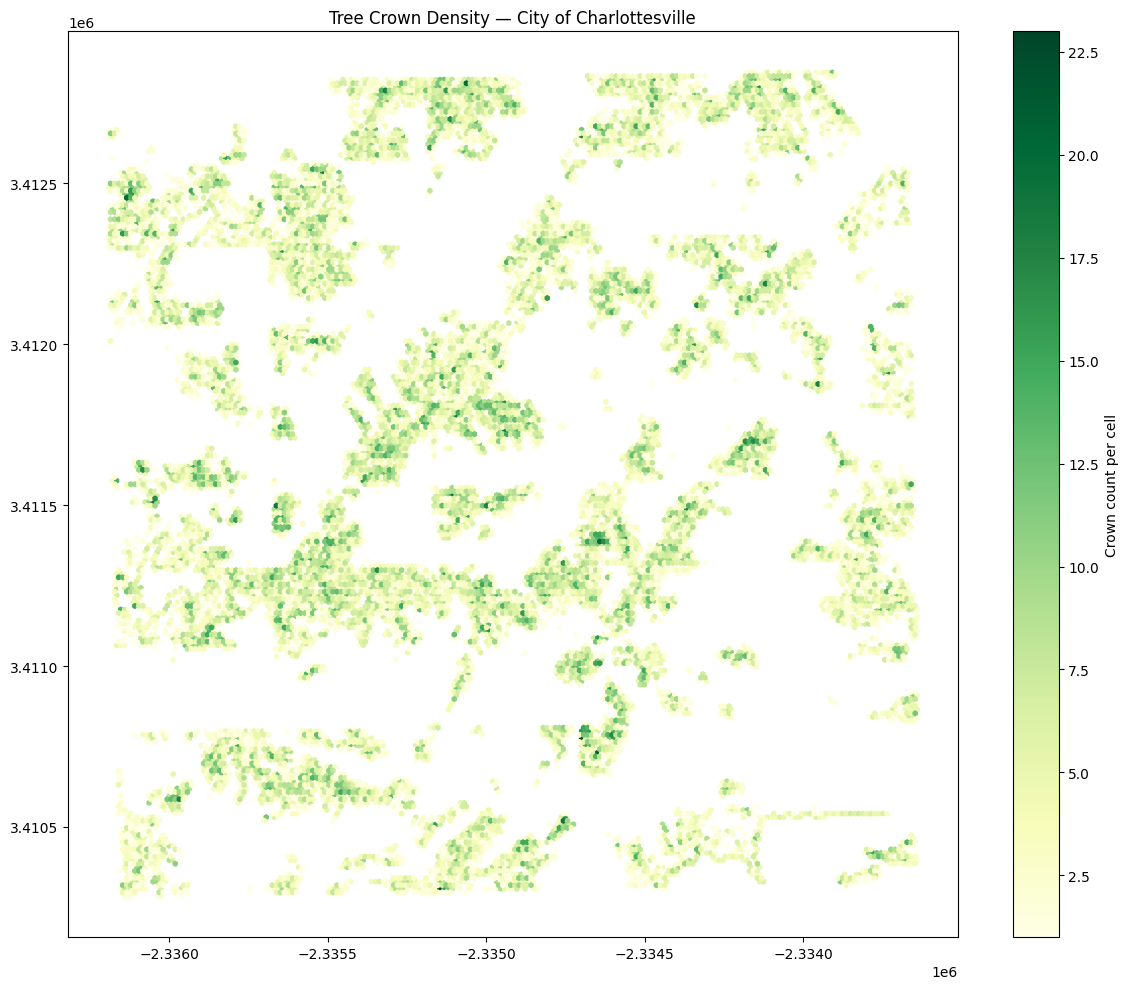

In [10]:
import pandas as pd
import pyproj
import matplotlib.pyplot as plt

df = pd.read_csv("s3://central-virginia-tree-canopy-project/centroids/all_2016_centroids.csv")

transformer = pyproj.Transformer.from_crs("EPSG:2284", "EPSG:32618", always_xy=True)
df['utm_easting'], df['utm_northing'] = transformer.transform(
    df['easting_m'].values, df['northing_m'].values
)

fig, ax = plt.subplots(figsize=(12, 10))
hb = ax.hexbin(df.utm_easting, df.utm_northing, gridsize=200, cmap='YlGn', mincnt=1)
plt.colorbar(hb, ax=ax, label='Crown count per cell')
ax.set_title('Tree Crown Density — City of Charlottesville')
plt.tight_layout()
plt.show()   # renders inline in the notebook cell


In [13]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# ── Load the master centroid CSV produced by the pipeline ──────────────────
df1 = pd.read_csv("s3://central-virginia-tree-canopy-project/centroids/all_2016_centroids.csv")

# Preview
print(f"Total crowns loaded: {len(df1):,}")
print(df1.head())

Total crowns loaded: 64,784
                                             tile_id    easting_m  \
0  USGS_LPC_VA_ChesapeakeBay_2015_LAS_S13_4879_30...  3497618.495   
1  USGS_LPC_VA_ChesapeakeBay_2015_LAS_S13_4879_30...  3497815.495   
2  USGS_LPC_VA_ChesapeakeBay_2015_LAS_S13_4879_30...  3498488.495   
3  USGS_LPC_VA_ChesapeakeBay_2015_LAS_S13_4879_30...  3498544.495   
4  USGS_LPC_VA_ChesapeakeBay_2015_LAS_S13_4879_30...  3498570.495   

    northing_m  height_m  
0  1188721.874     45.23  
1  1188721.874     59.70  
2  1188721.874     45.07  
3  1188721.874     34.45  
4  1188721.874     26.70  


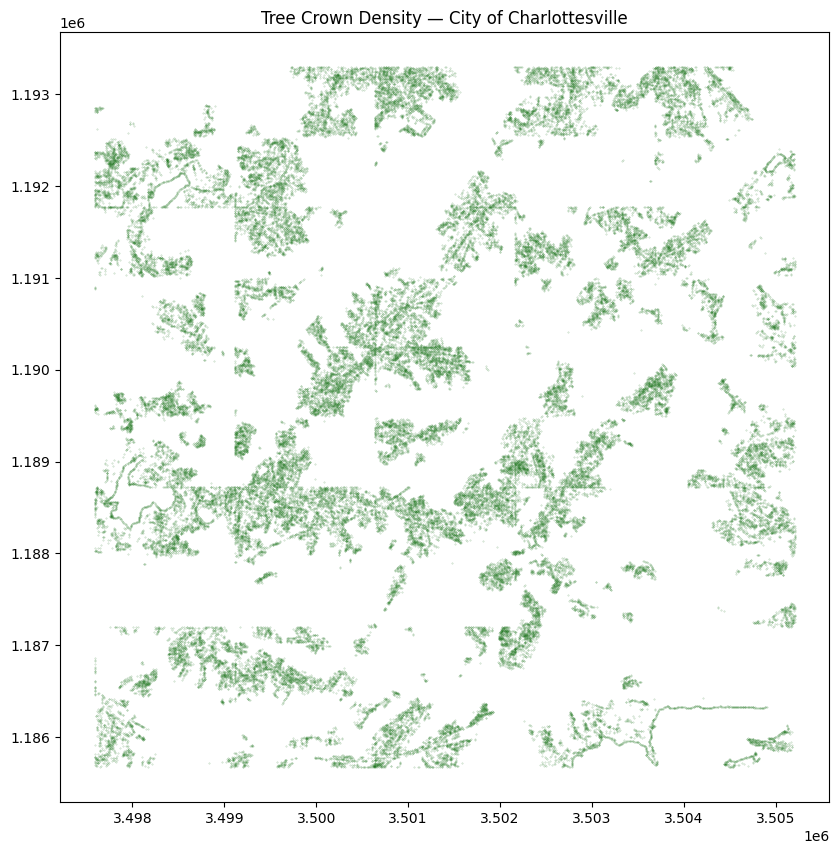

In [14]:
# ── Convert to GeoDataFrame (UTM Zone 18N) ─────────────────────────────────
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df.easting_m, df.northing_m),
    crs="EPSG:32618"
)

# ── Hexbin density map ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 10))
gdf.plot(ax=ax, markersize=0.1, alpha=0.3, color='darkgreen')
ax.set_title("Tree Crown Density — City of Charlottesville")
plt.show()